# Assignment 4: Decision Trees

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = ['buying', 'maint', 'doors', "persons", "lug_boot", "safety", "accept"]

df = pd.read_csv("car.data", header=None, names=cols)

attributes = list(df.columns[:-1])
target = df.columns[-1]
X = df[attributes]
y = df[target]

print("Attributes:")
print(X.head())
print()
print("Target:")
print(y.head())

Attributes:
  buying  maint doors persons lug_boot safety
0  vhigh  vhigh     2       2    small    low
1  vhigh  vhigh     2       2    small    med
2  vhigh  vhigh     2       2    small   high
3  vhigh  vhigh     2       2      med    low
4  vhigh  vhigh     2       2      med    med

Target:
0    unacc
1    unacc
2    unacc
3    unacc
4    unacc
Name: accept, dtype: str


In [2]:
class ID3DecisionTree:
    def __init__(self, impurity_metric='entropy', max_depth=None, max_impurity=0.0):
        self.impurity_metric = impurity_metric
        self.max_depth = max_depth
        self.max_impurity = max_impurity
        self.depth_impurities = {}
        self.tree = None
        self.accuracy_history = {'train': [], 'val': [], 'test': []}

    def _get_impurity(self, y):
        if len(y) == 0: return 0
        probs = y.value_counts(normalize=True)
        
        if self.impurity_metric == 'entropy':
            return -np.sum(probs * np.log2(probs + 1e-9))
        elif self.impurity_metric == 'gini':
            return 1 - np.sum(probs**2)
        return 0

    def _information_gain(self, X, y, attribute):
        total_impurity = self._get_impurity(y)
        values = X[attribute].unique()
        weighted_impurity = 0
        
        split_info = 0
        
        for val in values:
            subset_y = y[X[attribute] == val]
            weight = len(subset_y) / len(y)
            weighted_impurity += weight * self._get_impurity(subset_y)
            split_info -= weight * np.log2(weight + 1e-9)

        gain = total_impurity - weighted_impurity
        
        if self.impurity_metric == 'gain_ratio':
            return gain / (split_info + 1e-9)
        return gain

    def fit(self, X, y, depth=0):
        if depth == 0:
            self._total_train_size = len(y)
            
        node_impurity = self._get_impurity(y)
        weight = len(y) / len(train_df)
        self.depth_impurities.setdefault(depth, 0)
        self.depth_impurities[depth] += (node_impurity * weight)
        
        if len(y.unique()) == 1 or (self.max_depth and depth >= self.max_depth):
            return y.mode()[0]
        
        gains = {attr: self._information_gain(X, y, attr) for attr in X.columns}
        if not gains or max(gains.values()) <= 0:
            return y.mode()[0]
            
        best_attr = max(gains, key=gains.get)
        current_node_tree = {best_attr: {}}
        
        for val in X[best_attr].unique():
            X_subset = X[X[best_attr] == val].drop(columns=[best_attr])
            y_subset = y[X[best_attr] == val]
            if not y_subset.empty:
                current_node_tree[best_attr][val] = self.fit(X_subset, y_subset, depth + 1)
        
        if depth == 0:
            self.tree = current_node_tree
            
        return current_node_tree

    def predict(self, row, tree=None):
        if tree is None:
            tree = self.tree
        
        if not isinstance(tree, dict):
            return tree
            
        attr = next(iter(tree))
        val = row.get(attr)
        
        if val in tree[attr]:
            return self.predict(row, tree[attr][val])
        return "unacc"

    def compute_accuracy(self, data):
        if self.tree is None: return 0
        preds = data.apply(lambda r: self.predict(r), axis=1)
        return (preds == data[target]).mean()

    def get_rules(self, tree=None, path=""):
        if tree is None: tree = self.tree
        if not isinstance(tree, dict):
            return f" THEN {target} = {tree}"
        
        rules = []
        attr = next(iter(tree))
        for val, subtree in tree[attr].items():
            current_path = f"({attr} = {val})"
            if path: current_path = f"{path} AND {current_path}"
            
            if isinstance(subtree, dict):
                rules.append(self.get_rules(subtree, current_path))
            else:
                rules.append(f"IF {current_path} THEN {target} = {subtree}")
        return " OR ".join(rules)

def prepare_data(df, train_seg, val_seg, percent_noise, with_replacement=False):
    if percent_noise > 0:
        n_samples = int((percent_noise / 100) * df.size)
        for _ in range(n_samples):
            row = np.random.randint(0, df.shape[0])
            col = np.random.randint(0, df.shape[1] - 1)
            col_name = df.columns[col]
            df.iat[row, col] = np.random.choice(df[col_name].unique())

    df_shuffled = df.sample(frac=1, replace=with_replacement).reset_index(drop=True)
    
    train_end = int(len(df) * (train_seg / 100))
    val_end = train_end + int(len(df) * (val_seg / 100))
    
    train = df_shuffled.iloc[:train_end]
    val = df_shuffled.iloc[train_end:val_end]
    test = df_shuffled.iloc[val_end:]
    
    return train, val, test

In [3]:
def fig_id_generator():
    i = 1
    while True:
        yield i
        i += 1

fig_id = fig_id_generator()

def plot_impurity(depths, impurity_valuesu):
    plt.figure(figsize=(8, 4))
    plt.plot(depths, impurity_values, marker='o', color='red')
    plt.title("Requirement (a): Gradual Reduction of Total Impurity")
    plt.xlabel("Tree Depth (Level of Branching)")
    plt.ylabel("Weighted Total Entropy")
    plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
    plt.grid(True)
    plt.show() 
    
def plot_accuracy_curves(train, val, test, impurity_metric="entropy", max_depth=15, max_impurity=0):
    train_accs, val_accs, test_accs = [], [], []
    depths = range(1, max_depth)
    
    for d in depths:
        classifier = ID3DecisionTree(impurity_metric=impurity_metric, max_depth=d, max_impurity=max_impurity)
        classifier.fit(X, y)
        train_accs.append(classifier.compute_accuracy(train))
        val_accs.append(classifier.compute_accuracy(val))
        test_accs.append(classifier.compute_accuracy(test))
        
    plt.figure(figsize=(8, 4))
    plt.plot(depths, train_accs, label='Train')
    plt.plot(depths, val_accs, label='Validation')
    plt.plot(depths, test_accs, label='Test')
    plt.title("Accuracy Curves vs Node Branching (Depth)")
    plt.legend()
    plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
    plt.show()

## Setting - 0

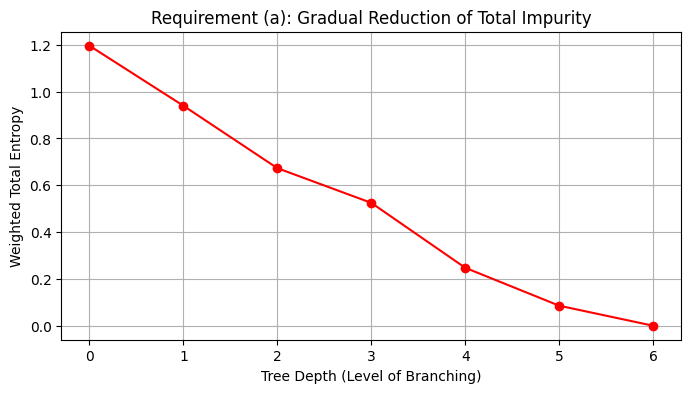

--- Decision Tree Rule-Set ---
IF (safety = med) AND (persons = 4) AND (maint = low) AND (buying = low) AND (lug_boot = med) THEN accept = acc OR IF (safety = med) AND (persons = 4) AND (maint = low) AND (buying = low) AND (lug_boot = big) THEN accept = good OR IF (safety = med) AND (persons = 4) AND (maint = low) AND (buying = low) AND (lug_boot = small) THEN accept = acc OR IF (safety = med) AND (persons = 4) AND (maint = low) AND (buying = high) AND (lug_boot = big) THEN accept = acc OR IF (safety = med) AND (persons = 4) AND (maint = low) AND (buying = high) AND (lug_boot = med) AND (doors = 2) THEN accept = unacc OR IF (safety = med) AND (persons = 4) AND (maint = low) AND (buying = high) AND (lug_boot = med) AND (doors = 5more) THEN accept = acc OR IF (safety = med) AND (persons = 4) AND (maint = low) AND (buying = high) AND (lug_boot = med) AND (doors = 4) THEN accept = acc OR IF (safety = med) AND (persons = 4) AND (maint = low) AND (buying = high) AND (lug_boot = med) AND (doo

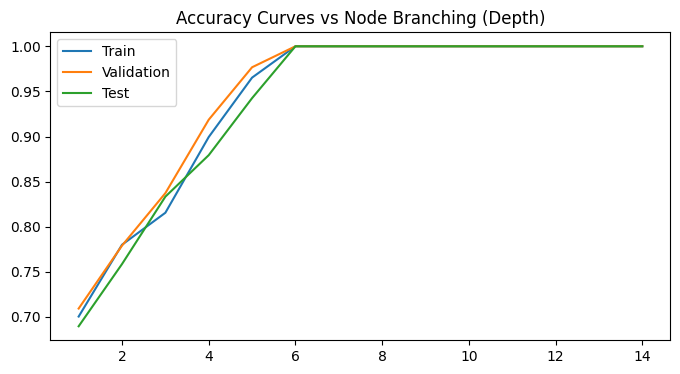

In [4]:
train_df, val_df, test_df = prepare_data(df, train_seg=80, val_seg=10, percent_noise=0)

classifier = ID3DecisionTree(impurity_metric='entropy', max_depth=None, max_impurity=0)
classifier.fit(train_df[attributes], train_df[target])

depths = sorted(classifier.depth_impurities.keys())
impurity_values = [classifier.depth_impurities[d] for d in depths]
plot_impurity(depths, impurity_values)

print("--- Decision Tree Rule-Set ---")
print(classifier.get_rules())

print(f"\nFinal Training Accuracy: {classifier.compute_accuracy(train_df):.2%}")
print(f"Final Validation Accuracy: {classifier.compute_accuracy(val_df):.2%}")
print(f"Final Testing Accuracy: {classifier.compute_accuracy(test_df):.2%}")

plot_accuracy_curves(train_df, val_df, test_df)

## Setting - 1

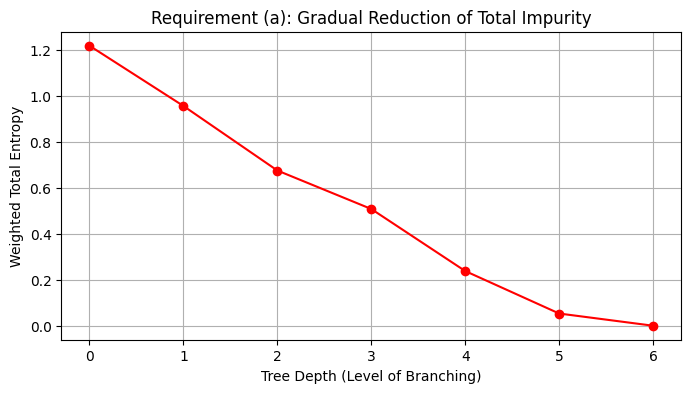

--- Decision Tree Rule-Set ---
IF (safety = med) AND (persons = more) AND (lug_boot = med) AND (maint = vhigh) AND (doors = 3) AND (buying = high) THEN accept = unacc OR IF (safety = med) AND (persons = more) AND (lug_boot = med) AND (maint = vhigh) AND (doors = 3) AND (buying = low) THEN accept = acc OR IF (safety = med) AND (persons = more) AND (lug_boot = med) AND (maint = vhigh) AND (doors = 2) THEN accept = unacc OR IF (safety = med) AND (persons = more) AND (lug_boot = med) AND (maint = vhigh) AND (doors = 4) THEN accept = acc OR IF (safety = med) AND (persons = more) AND (lug_boot = med) AND (maint = vhigh) AND (doors = 5more) THEN accept = unacc OR IF (safety = med) AND (persons = more) AND (lug_boot = med) AND (maint = low) AND (buying = vhigh) THEN accept = acc OR IF (safety = med) AND (persons = more) AND (lug_boot = med) AND (maint = low) AND (buying = low) AND (doors = 4) THEN accept = good OR IF (safety = med) AND (persons = more) AND (lug_boot = med) AND (maint = low) AN

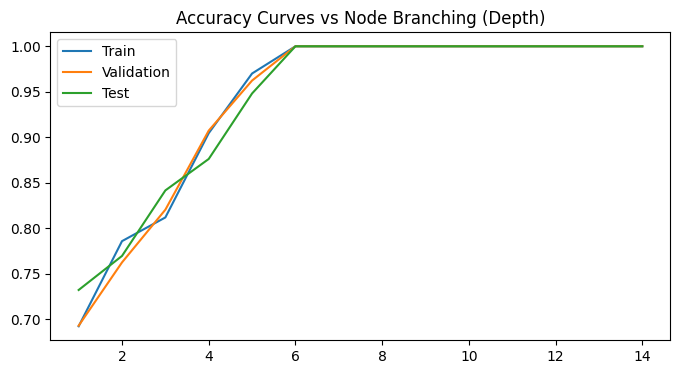

In [5]:
train_df, val_df, test_df = prepare_data(df, train_seg=60, val_seg=20, percent_noise=0)

classifier = ID3DecisionTree(impurity_metric='entropy', max_depth=None, max_impurity=0)
classifier.fit(train_df[attributes], train_df[target])

depths = sorted(classifier.depth_impurities.keys())
impurity_values = [classifier.depth_impurities[d] for d in depths]
plot_impurity(depths, impurity_values)

print("--- Decision Tree Rule-Set ---")
print(classifier.get_rules())

print(f"\nFinal Training Accuracy: {classifier.compute_accuracy(train_df):.2%}")
print(f"Final Validation Accuracy: {classifier.compute_accuracy(val_df):.2%}")
print(f"Final Testing Accuracy: {classifier.compute_accuracy(test_df):.2%}")

plot_accuracy_curves(train_df, val_df, test_df)

## Setting 2

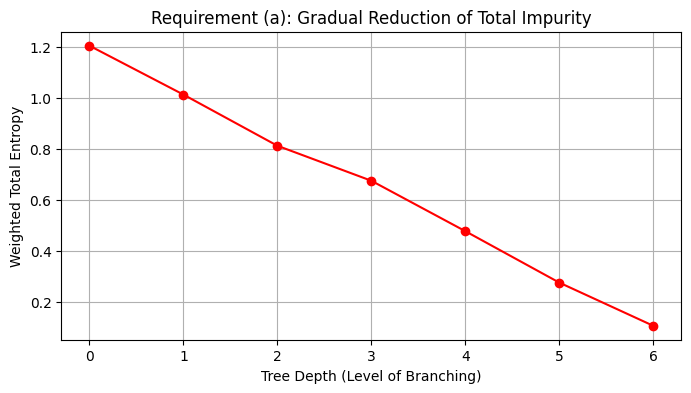

--- Decision Tree Rule-Set ---
IF (safety = high) AND (persons = more) AND (buying = high) AND (maint = vhigh) AND (doors = 5more) THEN accept = unacc OR IF (safety = high) AND (persons = more) AND (buying = high) AND (maint = vhigh) AND (doors = 4) AND (lug_boot = small) THEN accept = unacc OR IF (safety = high) AND (persons = more) AND (buying = high) AND (maint = vhigh) AND (doors = 4) AND (lug_boot = med) THEN accept = acc OR IF (safety = high) AND (persons = more) AND (buying = high) AND (maint = vhigh) AND (doors = 3) THEN accept = unacc OR IF (safety = high) AND (persons = more) AND (buying = high) AND (maint = vhigh) AND (doors = 2) THEN accept = unacc OR IF (safety = high) AND (persons = more) AND (buying = high) AND (maint = high) AND (lug_boot = small) AND (doors = 4) THEN accept = acc OR IF (safety = high) AND (persons = more) AND (buying = high) AND (maint = high) AND (lug_boot = small) AND (doors = 5more) THEN accept = unacc OR IF (safety = high) AND (persons = more) AND 

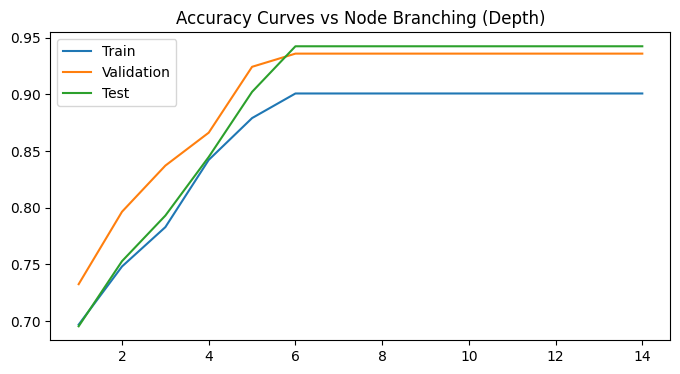

In [6]:
train_df, val_df, test_df = prepare_data(df, train_seg=80, val_seg=10, percent_noise=10)

classifier = ID3DecisionTree(impurity_metric='entropy', max_depth=None, max_impurity=0)
classifier.fit(train_df[attributes], train_df[target])

depths = sorted(classifier.depth_impurities.keys())
impurity_values = [classifier.depth_impurities[d] for d in depths]
plot_impurity(depths, impurity_values)

print("--- Decision Tree Rule-Set ---")
print(classifier.get_rules())

print(f"\nFinal Training Accuracy: {classifier.compute_accuracy(train_df):.2%}")
print(f"Final Validation Accuracy: {classifier.compute_accuracy(val_df):.2%}")
print(f"Final Testing Accuracy: {classifier.compute_accuracy(test_df):.2%}")

plot_accuracy_curves(train_df, val_df, test_df)

## Setting - 3

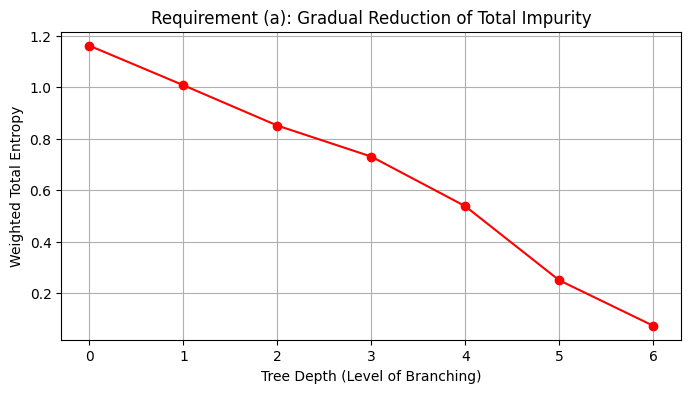

--- Decision Tree Rule-Set ---
IF (safety = low) AND (maint = vhigh) AND (buying = high) THEN accept = unacc OR IF (safety = low) AND (maint = vhigh) AND (buying = vhigh) THEN accept = unacc OR IF (safety = low) AND (maint = vhigh) AND (buying = low) AND (lug_boot = med) THEN accept = unacc OR IF (safety = low) AND (maint = vhigh) AND (buying = low) AND (lug_boot = big) THEN accept = unacc OR IF (safety = low) AND (maint = vhigh) AND (buying = low) AND (lug_boot = small) AND (doors = 4) THEN accept = unacc OR IF (safety = low) AND (maint = vhigh) AND (buying = low) AND (lug_boot = small) AND (doors = 3) THEN accept = acc OR IF (safety = low) AND (maint = vhigh) AND (buying = low) AND (lug_boot = small) AND (doors = 2) THEN accept = unacc OR IF (safety = low) AND (maint = vhigh) AND (buying = med) AND (doors = 3) THEN accept = unacc OR IF (safety = low) AND (maint = vhigh) AND (buying = med) AND (doors = 4) AND (persons = 2) AND (lug_boot = med) THEN accept = unacc OR IF (safety = low) 

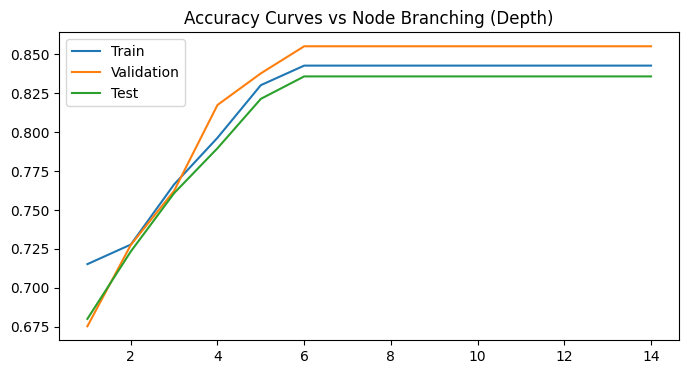

In [7]:
train_df, val_df, test_df = prepare_data(df, train_seg=60, val_seg=20, percent_noise=10)

classifier = ID3DecisionTree(impurity_metric='entropy', max_depth=None, max_impurity=0)
classifier.fit(train_df[attributes], train_df[target])

depths = sorted(classifier.depth_impurities.keys())
impurity_values = [classifier.depth_impurities[d] for d in depths]
plot_impurity(depths, impurity_values)

print("--- Decision Tree Rule-Set ---")
print(classifier.get_rules())

print(f"\nFinal Training Accuracy: {classifier.compute_accuracy(train_df):.2%}")
print(f"Final Validation Accuracy: {classifier.compute_accuracy(val_df):.2%}")
print(f"Final Testing Accuracy: {classifier.compute_accuracy(test_df):.2%}")

plot_accuracy_curves(train_df, val_df, test_df)

## Setting - 4

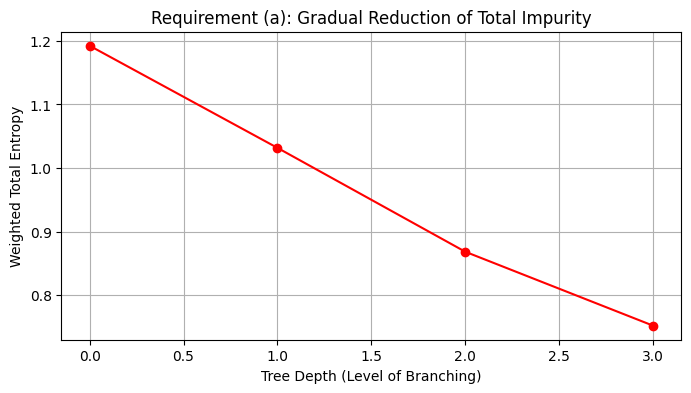

--- Decision Tree Rule-Set ---
IF (safety = low) AND (maint = high) AND (doors = 5more) THEN accept = unacc OR IF (safety = low) AND (maint = high) AND (doors = 4) THEN accept = unacc OR IF (safety = low) AND (maint = high) AND (doors = 2) THEN accept = unacc OR IF (safety = low) AND (maint = high) AND (doors = 3) THEN accept = unacc OR IF (safety = low) AND (maint = low) AND (doors = 4) THEN accept = unacc OR IF (safety = low) AND (maint = low) AND (doors = 5more) THEN accept = unacc OR IF (safety = low) AND (maint = low) AND (doors = 3) THEN accept = unacc OR IF (safety = low) AND (maint = low) AND (doors = 2) THEN accept = unacc OR IF (safety = low) AND (maint = med) AND (doors = 3) THEN accept = unacc OR IF (safety = low) AND (maint = med) AND (doors = 4) THEN accept = unacc OR IF (safety = low) AND (maint = med) AND (doors = 2) THEN accept = unacc OR IF (safety = low) AND (maint = med) AND (doors = 5more) THEN accept = unacc OR IF (safety = low) AND (maint = vhigh) AND (doors = 4)

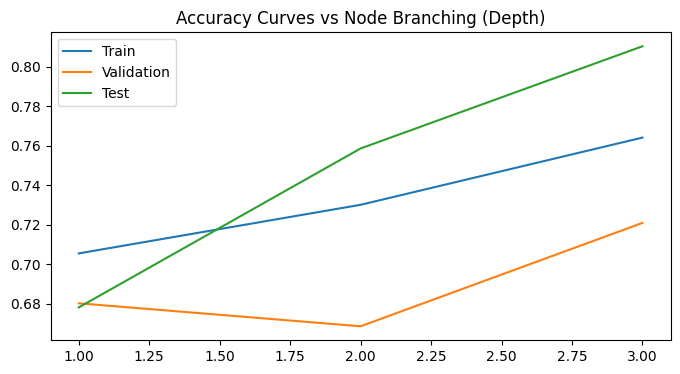

In [8]:
train_df, val_df, test_df = prepare_data(df, train_seg=80, val_seg=10, percent_noise=0)

classifier = ID3DecisionTree(impurity_metric='entropy', max_depth=3, max_impurity=0.25)
classifier.fit(train_df[attributes], train_df[target])

depths = sorted(classifier.depth_impurities.keys())
impurity_values = [classifier.depth_impurities[d] for d in depths]
plot_impurity(depths, impurity_values)

print("--- Decision Tree Rule-Set ---")
print(classifier.get_rules())

print(f"\nFinal Training Accuracy: {classifier.compute_accuracy(train_df):.2%}")
print(f"Final Validation Accuracy: {classifier.compute_accuracy(val_df):.2%}")
print(f"Final Testing Accuracy: {classifier.compute_accuracy(test_df):.2%}")

plot_accuracy_curves(train_df, val_df, test_df, max_depth=4, max_impurity=0.25)

## Setting - 5

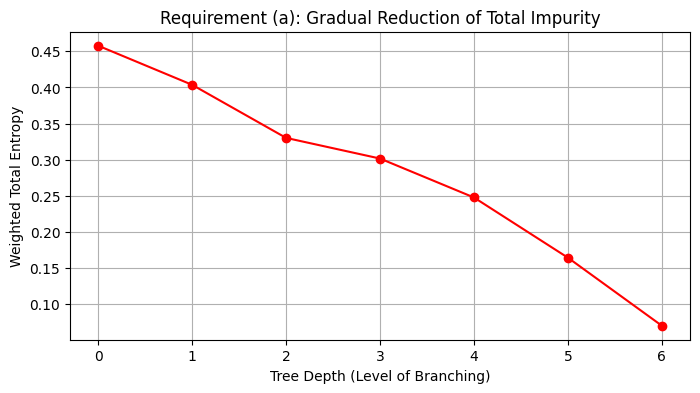

--- Decision Tree Rule-Set ---
IF (safety = low) AND (persons = more) AND (buying = vhigh) AND (doors = 3) THEN accept = unacc OR IF (safety = low) AND (persons = more) AND (buying = vhigh) AND (doors = 2) THEN accept = unacc OR IF (safety = low) AND (persons = more) AND (buying = vhigh) AND (doors = 4) AND (lug_boot = big) AND (maint = low) THEN accept = acc OR IF (safety = low) AND (persons = more) AND (buying = vhigh) AND (doors = 4) AND (lug_boot = big) AND (maint = high) THEN accept = unacc OR IF (safety = low) AND (persons = more) AND (buying = vhigh) AND (doors = 4) AND (lug_boot = small) THEN accept = unacc OR IF (safety = low) AND (persons = more) AND (buying = vhigh) AND (doors = 5more) THEN accept = unacc OR IF (safety = low) AND (persons = more) AND (buying = high) AND (lug_boot = big) AND (maint = med) AND (doors = 4) THEN accept = unacc OR IF (safety = low) AND (persons = more) AND (buying = high) AND (lug_boot = big) AND (maint = med) AND (doors = 3) THEN accept = acc OR

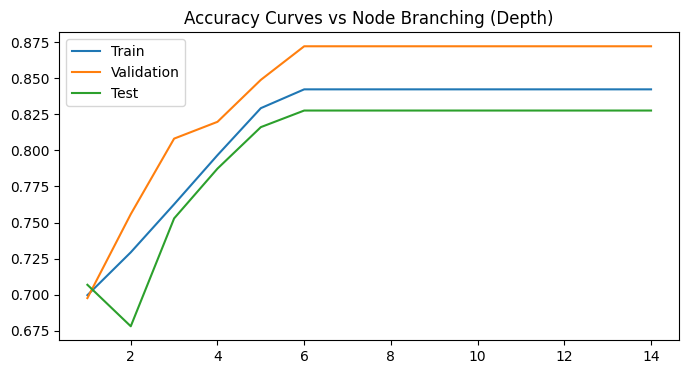

In [9]:
train_df, val_df, test_df = prepare_data(df, train_seg=80, val_seg=10, percent_noise=0)

classifier = ID3DecisionTree(impurity_metric='gini', max_depth=None, max_impurity=0)
classifier.fit(train_df[attributes], train_df[target])

depths = sorted(classifier.depth_impurities.keys())
impurity_values = [classifier.depth_impurities[d] for d in depths]
plot_impurity(depths, impurity_values)

print("--- Decision Tree Rule-Set ---")
print(classifier.get_rules())

print(f"\nFinal Training Accuracy: {classifier.compute_accuracy(train_df):.2%}")
print(f"Final Validation Accuracy: {classifier.compute_accuracy(val_df):.2%}")
print(f"Final Testing Accuracy: {classifier.compute_accuracy(test_df):.2%}")

plot_accuracy_curves(train_df, val_df, test_df, impurity_metric="gini")